In [48]:
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# **Generowanie danych**

### **Dane dla LDA/QDA/NB - 2 klasy, rozkłady normalne**

In [45]:
# scheme 1 - niezalezne cechy, spelnione zalozenia LDA
def generate_scheme1(n=1000, a=2):
    y = np.random.binomial(1, 0.5, size=n)
    X = np.zeros((n, 2))

    X[y == 0] = np.random.normal(0, 1, size=(np.sum(y == 0), 2))
    X[y == 1] = np.random.normal(a, 1, size=(np.sum(y == 1), 2))

    return X, y

In [2]:
# scheme 2 - cechy skorelowane, rozne macierze kowariancji
def generate_scheme2(n=1000, a=2, sigma=0.5):
    y = np.random.binomial(1, 0.5, size=n)

    mean0 = [0, 0]
    mean1 = [a, a]

    cov0 = [[1, sigma],
            [sigma, 1]]

    cov1 = [[1, -sigma],
            [-sigma, 1]]

    X = np.zeros((n, 2))
    X[y == 0] = np.random.multivariate_normal(mean0, cov0, size=np.sum(y == 0))
    X[y == 1] = np.random.multivariate_normal(mean1, cov1, size=np.sum(y == 1))

    return X, y

### **Mieszanka dwoch rozkladow normalnych - density estimation**

In [8]:
# rozkład:
# 0.9 * N(5, 1) + 0.1 * N(10, 1)

def generate_gaussian_mixture(n=200):
    cluster = np.random.binomial(1, 0.1, size=n)

    X = np.zeros(n)
    X[cluster == 0] = np.random.normal(5, 1, size=np.sum(cluster == 0))
    X[cluster == 1] = np.random.normal(10, 1, size=np.sum(cluster == 1))

    return X

### **Sztuczna próbka z KDE**

In [9]:
# w zadaniu generuje sie nowe punkty na podstawie juz istniejacej probki

def generate_kde_sample(X, k=5000, h=0.3):
    n = len(X)

    indices = np.random.randint(0, n, size=k)
    eps = np.random.normal(0, 1, size=k)

    X_artificial = X[indices] + eps * h

    return X_artificial

### **Dane z modelu regresji logistycznej**

In [10]:
# model
# X ~ N(0, I)
# P(Y = 1 | X) = sigmoid(beta0 + beta^T X)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def generate_logistic_data(n=50, p=5, beta0=0.5):
    X = np.random.normal(0, 1, size=(n, p))
    beta = np.ones(p)

    p_y = sigmoid(beta0 + X @ beta)
    y = np.random.binomial(1, p_y)

    return X, y

### **Dane do evalutaion methods - istotne i nieistotne zmienne**

In [11]:
# tu: pierwsze 5 zmiennych jest istotnych, reszta nieistotna

def generate_evaluation_data(n=1000, b=1, k=20, alpha=1):
    p = 5 + k
    X = np.random.normal(0, 1, size=(n, p))

    beta = np.array([b, b, b, b, b] + [0] * k)

    probs = sigmoid(alpha + X @ beta)
    y = np.random.binomial(1, probs)

    return X, y

### **Dane do LASSO - 10 istotnych i 10 nieistotnych**

In [12]:
def generate_lasso_data(n=300):
    p = 20
    X = np.random.normal(0, 1, size=(n, p))

    beta = np.array([1] * 10 + [0] * 10)

    probs = sigmoid(X @ beta)
    y = np.random.binomial(1, probs)

    return X, y

### **Probit type data generation**

In [13]:
# zamiast sigmoidy uzywa dystrybuanty rozkladu normalnego

from scipy.stats import norm

def generate_probit_data(n=300):
    p = 20
    X = np.random.normal(0, 1, size=(n, p))

    beta = np.array([1] * 10 + [0] * 10)

    probs = norm.cdf(X @ beta)
    y = np.random.binomial(1, probs)

    return X, y

### **Dane do ensemble methods - granica kulista**

In [14]:
# Y = 1, jeśli suma X_j^2 > mediana chi-square(10)
# Y = -1 w przeciwnym razie

from scipy.stats import chi2

def generate_ensemble_data(n=2000):
    X = np.random.normal(0, 1, size=(n, 10))

    threshold = chi2.ppf(0.5, df=10)

    y = np.where(np.sum(X**2, axis=1) > threshold, 1, -1)

    return X, y

### **Feature selection - dataset 1**

In [15]:
# pierwsze k zmiennych jest istotnych

def generate_feature_dataset1(n=500, p=50, k=10):
    X = np.random.normal(0, 1, size=(n, p))

    threshold = chi2.ppf(0.5, df=k)

    y = np.where(np.sum(X[:, :k]**2, axis=1) > threshold, 1, 0)

    return X, y

### **Feature selection - dataset 2**

In [16]:
def generate_feature_dataset2(n=500, p=50, k=10):
    X = np.random.normal(0, 1, size=(n, p))

    y = np.where(np.sum(np.abs(X[:, :k]), axis=1) > k, 1, 0)

    return X, y

### **SVM liniowo separowalne dane**

In [17]:
# kod z tresci
def generate_linear_svm_data():
    np.random.seed(42)

    n_strip = 16
    n_blob = 6000

    x0_1 = np.hstack([
        np.random.normal(scale=0.6, size=(n_strip, 1)),
        np.random.uniform(0.3, 0.8, size=(n_strip, 1))
    ])

    x0_2 = np.random.multivariate_normal(
        mean=[0, 10],
        cov=np.array([[4, 3.5], [3.5, 4]]),
        size=n_blob
    )

    X0 = np.vstack([x0_1, x0_2])
    y0 = np.zeros(n_strip + n_blob)

    x1_1 = np.hstack([
        np.random.normal(scale=0.6, size=(n_strip, 1)),
        np.random.uniform(-0.8, -0.3, size=(n_strip, 1))
    ])

    x1_2 = np.random.multivariate_normal(
        mean=[0, -10],
        cov=np.array([[4, 3.5], [3.5, 4]]),
        size=n_blob
    )

    X1 = np.vstack([x1_1, x1_2])
    y1 = np.ones(n_strip + n_blob)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    return X, y

### **SVM/SSL - make moons**

In [18]:
from sklearn.datasets import make_moons

def generate_moons_data(n=300, noise=0.25):
    X, y = make_moons(
        n_samples=n,
        noise=noise,
        random_state=123
    )
    return X, y

### **Regresja - sztuczna funkcja + szum normalny**

In [19]:
# y = g(x) + epsilon
# x ~ U[0, 4]
# epsilon ~ N(0, 0.1^2)

def g(x):
    return 4.26 * (np.exp(-x) - 4*np.exp(-2*x) + 3*np.exp(-3*x))

def generate_regression_data(n=200):
    X = np.random.uniform(0, 4, size=n)
    eps = np.random.normal(0, 0.1, size=n)

    y = g(X) + eps

    return X, y

### **Mieszanka trech Gaussow + klasy zależne od X1**

In [20]:
def generate_test_task2(n=1000):
    clusters = np.random.choice([0, 1, 2], size=n, p=[0.25, 0.25, 0.5])

    X1 = np.zeros(n)
    X1[clusters == 0] = np.random.normal(-1, 0.2, size=np.sum(clusters == 0))
    X1[clusters == 1] = np.random.normal(1, 0.2, size=np.sum(clusters == 1))
    X1[clusters == 2] = np.random.normal(5, 0.2, size=np.sum(clusters == 2))

    X_rest = np.random.normal(0, 1, size=(n, 9))

    X = np.column_stack([X1, X_rest])

    probs = np.where(X1 < 3, 0.1, 0.9)   # zaleznosc od X1
    y = np.random.binomial(1, probs)

    return X, y

In [21]:
X_train, y_train = generate_test_task2(n=1000)
X_test, y_test = generate_test_task2(n=1000)

In [25]:
# zadanie 1
data = pd.read_csv("weights.csv")
data.head()

,x,y
0,1,85.40
1,2,85.12
2,3,85.68
3,4,86.30
4,5,85.33


In [38]:
# nadaray-watson
def gaussian_kernel(x, x_i, h):
    u = (x - x_i) / h
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)


def nadaraya_watson(kernel_function, X, y, h, x):
    weights = kernel_function(x, X, h)
    denom = weights.sum()

    if denom < 1e-10:
        return np.nan

    return (weights @ y) / denom


def nw_predict(kernel_function, X_train, y_train, h, X_new):
    return np.array([
        nadaraya_watson(kernel_function, X_train, y_train, h, x)
        for x in X_new
    ])

In [39]:
# X = data.drop(columns="y")
# y = data["y"]

X = data["x"].values
y = data["y"].values

In [40]:
# losowy podzial na 4 foldy
np.random.seed(42)

n = len(X)
indices = np.random.permutation(n)

folds = np.array_split(indices, 4)

In [ ]:
# cv dla nadaraya-watson

In [42]:
h_values = np.linspace(0.1, 5, 30)
nw_cv_mse = []

for h in h_values:
    fold_mse = []

    for i in range(4):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(4) if j != i])

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_val = X[val_idx]
        y_val = y[val_idx]

        y_pred = nw_predict(gaussian_kernel, X_train, y_train, h, X_val)

        # mse = mean_squared_error(y_val, y_pred)
        mse = np.mean((y_val - y_pred)**2)
        fold_mse.append(mse)

    nw_cv_mse.append(np.mean(fold_mse))

In [43]:
nw_cv_mse = np.array(nw_cv_mse)

best_h = h_values[np.argmin(nw_cv_mse)]

print("Best h:", best_h)
print("Best NW CV-MSE:", np.min(nw_cv_mse))

Best h: 0.1
Best NW CV-MSE: nan


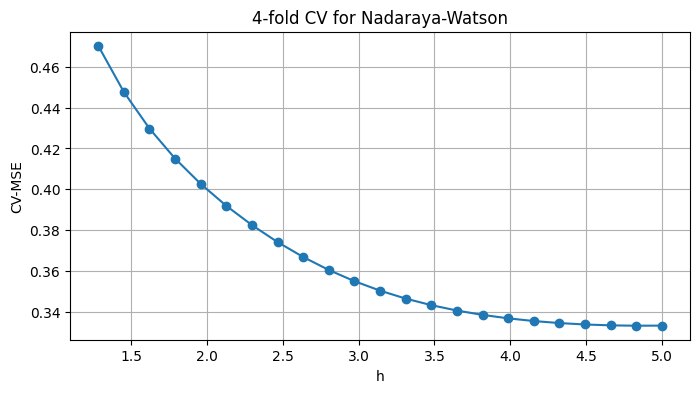

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(h_values, nw_cv_mse, marker="o")
plt.xlabel("h")
plt.ylabel("CV-MSE")
plt.title("4-fold CV for Nadaraya-Watson")
plt.grid(True)
plt.show()

In [49]:
# cv dla smoothing splines
s_values = np.linspace(0.1, 100, 30)
spline_cv_mse = []

for s in s_values:
    fold_mse = []

    for i in range(4):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(4) if j != i])

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_val = X[val_idx]
        y_val = y[val_idx]

        idx_sort = np.argsort(X_train)

        spline = UnivariateSpline(
            X_train[idx_sort],
            y_train[idx_sort],
            s=s,
            ext="const"
        )

        y_pred = spline(X_val)

        mse = mean_squared_error(y_val, y_pred)
        fold_mse.append(mse)

    spline_cv_mse.append(np.mean(fold_mse))

In [50]:
# wybor najlepszego

spline_cv_mse = np.array(spline_cv_mse)

best_s = s_values[np.argmin(spline_cv_mse)]

print("Best s:", best_s)
print("Best spline CV-MSE:", np.min(spline_cv_mse))

Best s: 20.768965517241384
Best spline CV-MSE: 0.3423297323894231


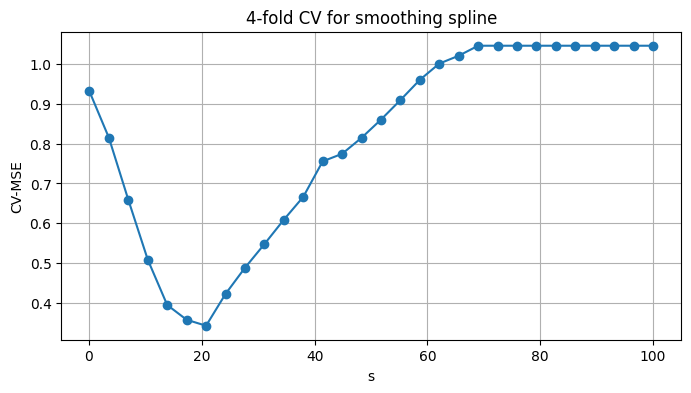

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(s_values, spline_cv_mse, marker="o")
plt.xlabel("s")
plt.ylabel("CV-MSE")
plt.title("4-fold CV for smoothing spline")
plt.grid(True)
plt.show()

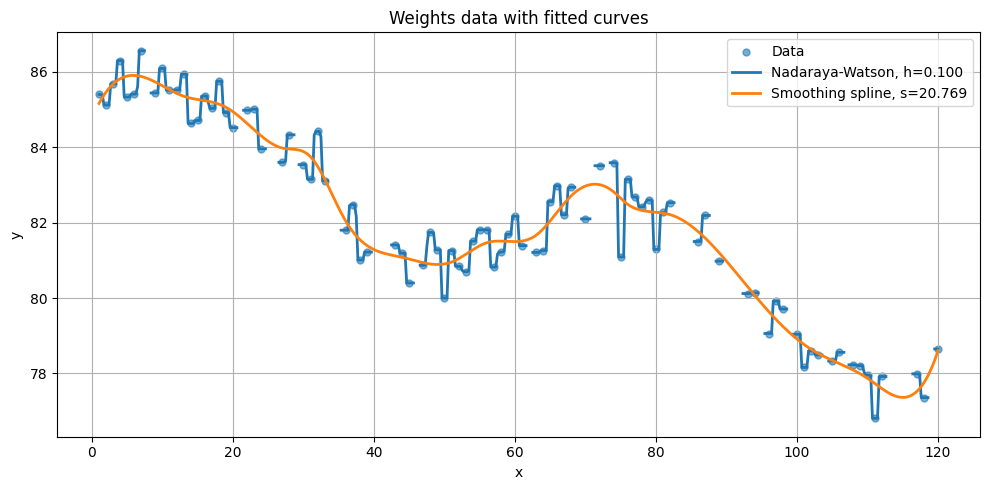

In [52]:
# dopasowanie do najlepszych
x_grid = np.linspace(X.min(), X.max(), 500)

# ndaraya-watson
y_nw = nw_predict(gaussian_kernel, X, y, best_h, x_grid)

# smoothing spline
idx_sort = np.argsort(X)

best_spline = UnivariateSpline(
    X[idx_sort],
    y[idx_sort],
    s=best_s,
    ext="const"
)

y_spline = best_spline(x_grid)

# wykres koncowy
plt.figure(figsize=(10, 5))

plt.scatter(X, y, s=25, alpha=0.6, label="Data")

plt.plot(
    x_grid,
    y_nw,
    linewidth=2,
    label=f"Nadaraya-Watson, h={best_h:.3f}"
)

plt.plot(
    x_grid,
    y_spline,
    linewidth=2,
    label=f"Smoothing spline, s={best_s:.3f}"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Weights data with fitted curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

male h -> bardzo falujaca krzywa, moze sie przeuczac<br>
duze h -> bardzo gladka krzywa, moze nie wylapywac lokalnych zmian


s - kontroluje wygladzenie<br>
male s -> spline mocniej dopasowuje sie do punktow<br>
duze s -> gladszy spline